In [4]:
from md_Helpers.master_csv import (
    build_results_inventory_csv,
    inventory_result_files,
    summarize_results_inventory,
)

table = build_results_inventory_csv()
summary = summarize_results_inventory(table)


In [5]:
from md_Helpers import master_csv, paths

eos_master = master_csv.build_thermalization_master_csv(
    n_fcc_cells=30,
    output_name="thermalization_master_ncells_30.csv",
    n_last=100,
)

eos_path = paths.MASTER_CSVS_V3_ROOT / "thermalization_master_ncells_30.csv"
eos_path


PosixPath('/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/thermalization_master_ncells_30.csv')

Thermalized state exists: checking phase separation.
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.600/kT_1.000/nsteps_1000000/seed_1/randomization.gsd
Thermalized state good; continuing to cavitation.


Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.600/kT_1.000/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_7.000/center_box/cavitation_initial.gsd


Loaded existing cavitation evolution:
/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.600/kT_1.000/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_7.000/center_box/evolve_kT_1.000/nsteps_100000/seed_1/cavitation_final.gsd


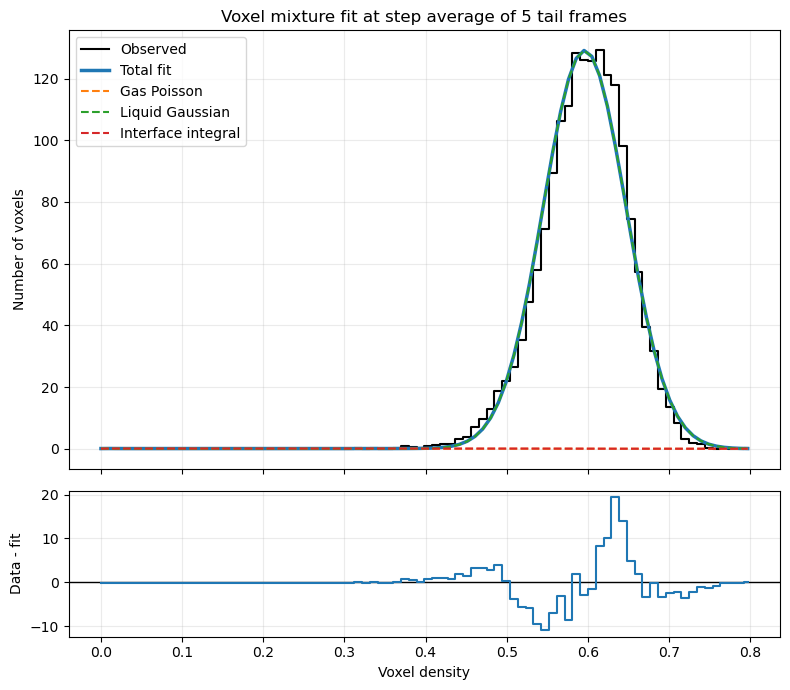

-181.03270910994505

In [1]:
from md_Helpers import cavitation, seitz

bubble = cavitation.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.60,
    kT=1.00,
    source_nsteps=1_000_000,
    radius=7.0,
    evolve_nsteps=100_000,
    evolve_seed=1,
)

terms = seitz.extract_bubble_state_terms(
    metadata_path=bubble["paths"]["log_path"],
)

terms
terms["Q"]

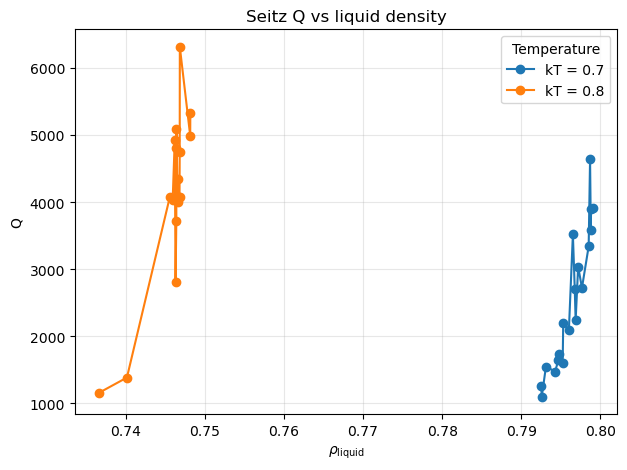

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers import paths

seitz_path = paths.MASTER_CSVS_V3_ROOT / "seitz_master.csv"
seitz = pd.read_csv(seitz_path)

plot_data = (
    seitz[
        (seitz["status"] == "seitz_computed")
        & seitz["Q"].notna()
        & seitz["rho_liquid"].notna()
        & seitz["source_kT"].notna()
    ]
    .sort_values(["source_kT", "rho_liquid"])
)

fig, ax = plt.subplots(figsize=(7, 5))

for kT, group in plot_data.groupby("source_kT"):
    ax.plot(
        group["rho_liquid"],
        group["Q"],
        marker="o",
        linewidth=1.5,
        label=f"kT = {kT:g}",
    )

ax.set_xlabel(r"$\rho_\mathrm{liquid}$")
ax.set_ylabel("Q")
ax.set_title("Seitz Q vs liquid density")
ax.legend(title="Temperature")
ax.grid(True, alpha=0.3)

plt.show()